In [1]:
import sys
from vrae.vrae import VRAE
from vrae.utils import *
import numpy as np
import torch
import pandas as pd
import plotly
from torch.utils.data import TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import xgboost as xgb

In [2]:
def my_scaler(data, feature_range = (0,1)): #list of series
    global_min = np.min([np.min(np.log(serie)) for serie in data])
    global_max = np.max([np.max(np.log(serie)) for serie in data])
    data_scaled = []
    for serie in data:
        serie = np.log(serie)
        serie = (serie - global_min) / (global_max - global_min)
        serie = serie * (feature_range[1] - feature_range[0]) + feature_range[0]
        data_scaled.append(serie)
    return(data_scaled)

#### import model
latent_length = 12
##################
sequence_length = 72
number_of_features = 1

dload = './model_save' #model save directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 1
learning_rate = 0.001 # 0.0005
n_epochs = 200
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae = VRAE(sequence_length=sequence_length,
            number_of_features = number_of_features,
            hidden_size = hidden_size, 
            hidden_layer_depth = hidden_layer_depth,
            latent_length = latent_length,
            batch_size = batch_size,
            learning_rate = learning_rate,
            n_epochs = n_epochs,
            dropout_rate = dropout_rate,
            optimizer = optimizer, 
            cuda = cuda,
            print_every=print_every, 
            clip=clip, 
            max_grad_norm=max_grad_norm,
            loss = loss,
            block = block,
            dload = dload)

vrae.load(fr'C:\Users\achfr\single_cell_time_series_representation_learning\model_12.pth')

#### importing dataset
df = pd.read_pickle(fr'C:\Users\achfr\single_cell_time_series_representation_learning\growth_antibiotic_dataset.csv')

df_tracks= df.pivot(values=[
    'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
    'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
    'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
    'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
    'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
    'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
    index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
    columns='Time')


#### Creating dataset and splitting it into train and test sets then data augmentation
liste_x=[]
liste_y=[]

dataset_name_list_control = ['gly_control_1','gly_control_2','gly_control_3','glu_control_1','glu_control_2','gluaa_control_1','gluaa_control_2']
dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
 'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']

def process_track_data(
    df_tracks=df_tracks, 
    dataset_name_list=dataset_name_list):
    liste_x=[]
    liste_y=[]
    
    for exp_name in dataset_name_list:
        medium,treatment,replicate = exp_name.split('_')
        
        frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
        size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
        cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
        sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
        mch_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])
        divisionrate_array = np.array([list(frame['DivisionRate'].T[k]) for k in frame['DivisionRate'].T.keys()])
        GrowthRateFeretMax_array = np.array([list(frame['GrowthRateFeretMax'].T[k]) for k in frame['GrowthRateFeretMax'].T.keys()])
        
        for i in range(size_array.shape[0]):
            size_serie =  size_array[i]
            ##fill nans missing timepoints with the mean of the previous and next timepoints
            for j in range(1,len(size_serie)-1):
                if np.isnan(size_serie[j]):
                    size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])
            
            cyclefate_serie = cyclefate_array[i]
            ##fill nans missing timepoints with the next fate timepoint
            for j in range(len(cyclefate_serie)-1):
                if cyclefate_serie[j] == 'nan':
                    cyclefate_serie[j] = cyclefate_serie[j+1]
            
            sos_serie = sos_array[i]
            for j in range(1,len(sos_serie)-1):
                if np.isnan(sos_serie[j]):
                    sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
            
            mch_serie = mch_array[i]
            for j in range(1,len(mch_serie)-1):
                if np.isnan(mch_serie[j]):
                    mch_serie[j] = np.mean([mch_serie[j-1],mch_serie[j+1]])
            
            divisionrate_serie = divisionrate_array[i]
            for j in range(1,len(divisionrate_serie)-1):
                if np.isnan(divisionrate_serie[j]):
                    divisionrate_serie[j] = np.mean([divisionrate_serie[j-1],divisionrate_serie[j+1]])
            
            GrowthRateFeretMax_serie = GrowthRateFeretMax_array[i]
            for j in range(1,len(GrowthRateFeretMax_serie)-1):
                if np.isnan(GrowthRateFeretMax_serie[j]):
                    GrowthRateFeretMax_serie[j] = np.mean([GrowthRateFeretMax_serie[j-1],GrowthRateFeretMax_serie[j+1]])
            
            t_death = len(cyclefate_serie)
            if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
                t_death = np.where(cyclefate_serie != 'alive')[0][0]
            
            # first_nan_idx = len(size_serie)
            # if np.where(np.isnan(size_serie))[0].shape[0] > 0:
            #     first_nan_idx = np.where(np.isnan(size_serie))[0][0]    
            
            usable_data = size_serie[:min(t_death,288)] # use data until cell death or 288 frames (24h), whichever comes first
            if len(usable_data) > 72: #only keep tracks with at least 6 hours of data
                liste_x.append([size_serie[:min(t_death,288)], sos_serie[:min(t_death,288)], mch_serie[:min(t_death,288)], divisionrate_serie[:min(t_death,288)], GrowthRateFeretMax_serie[:min(t_death,288)]])
                liste_y.append((medium,treatment,replicate,t_death))

    if len(liste_x) == 0:
        raise ValueError("No usable data found. Please check the dataset and criteria.")
    return liste_x, liste_y

liste_x, liste_y = process_track_data(df_tracks=df_tracks, dataset_name_list=dataset_name_list)

n_estimators: 10, r2: 0.9487
n_estimators: 50, r2: 0.9518
n_estimators: 100, r2: 0.9517
n_estimators: 200, r2: 0.9512
n_estimators: 500, r2: 0.9507
n_estimators: 1000, r2: 0.9507
n_estimators: 10, r2: 0.7533
n_estimators: 50, r2: 0.7573
n_estimators: 100, r2: 0.7528
n_estimators: 200, r2: 0.7506
n_estimators: 500, r2: 0.7508
n_estimators: 1000, r2: 0.7508
n_estimators: 10, r2: 0.9687
n_estimators: 50, r2: 0.9719
n_estimators: 100, r2: 0.9716
n_estimators: 200, r2: 0.9712
n_estimators: 500, r2: 0.9709
n_estimators: 1000, r2: 0.9709
n_estimators: 10, r2: 0.9102
n_estimators: 50, r2: 0.9117
n_estimators: 100, r2: 0.9123
n_estimators: 200, r2: 0.9123
n_estimators: 500, r2: 0.9121
n_estimators: 1000, r2: 0.9121


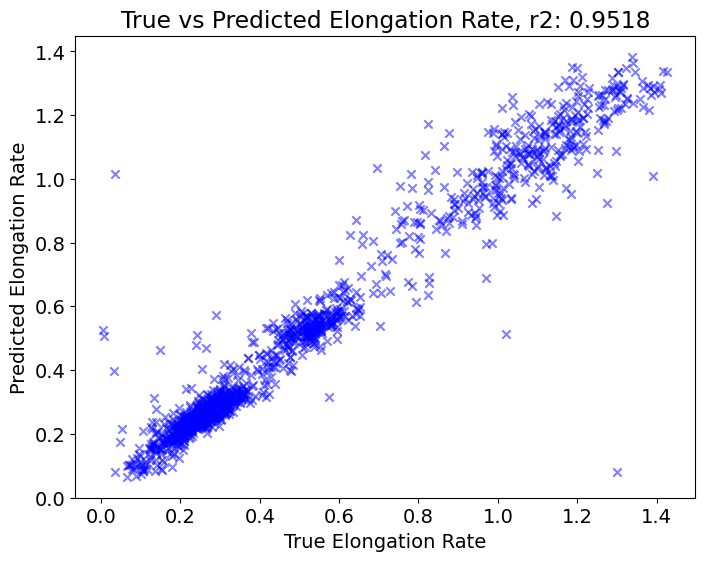

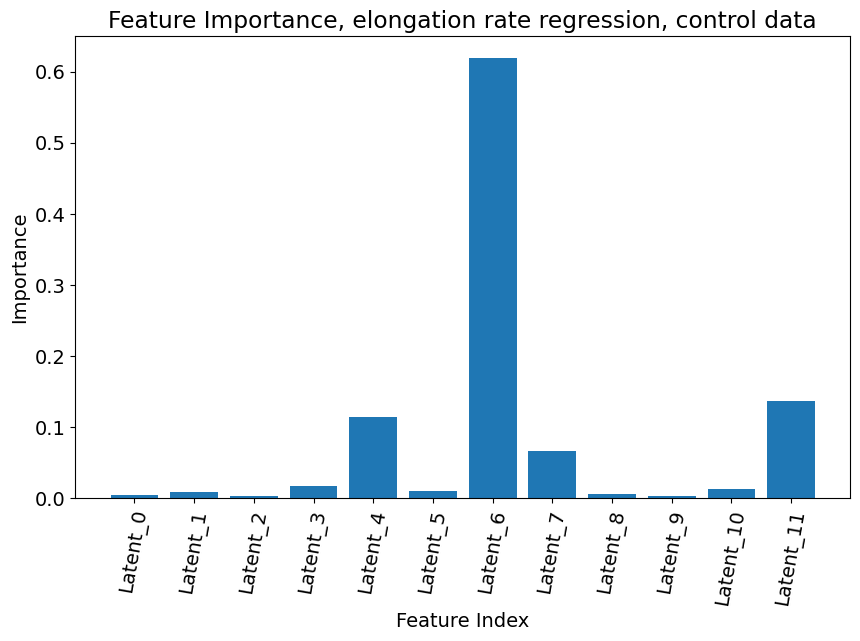

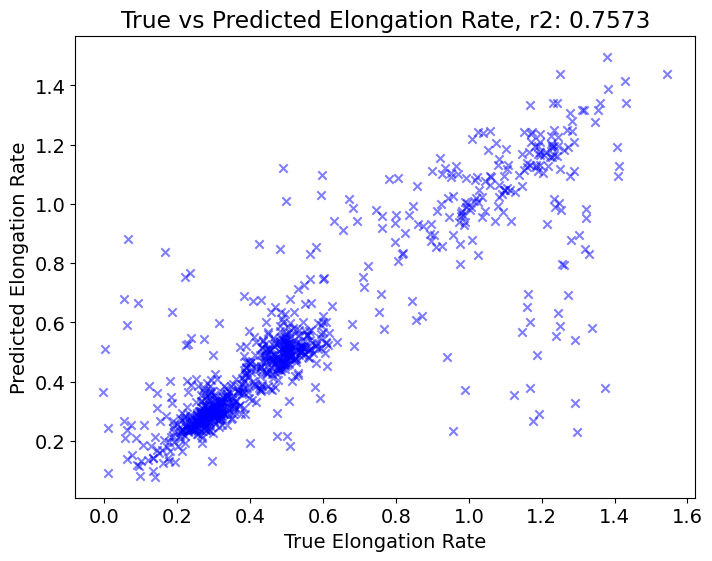

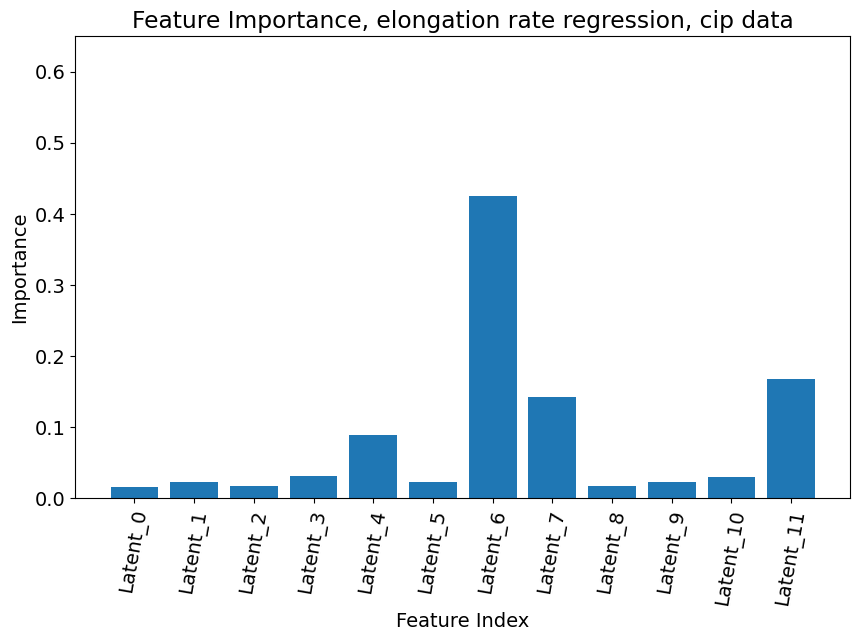

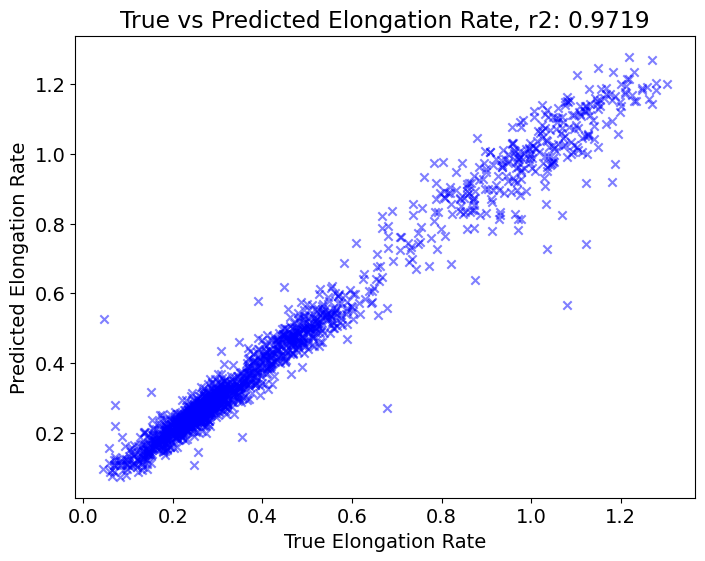

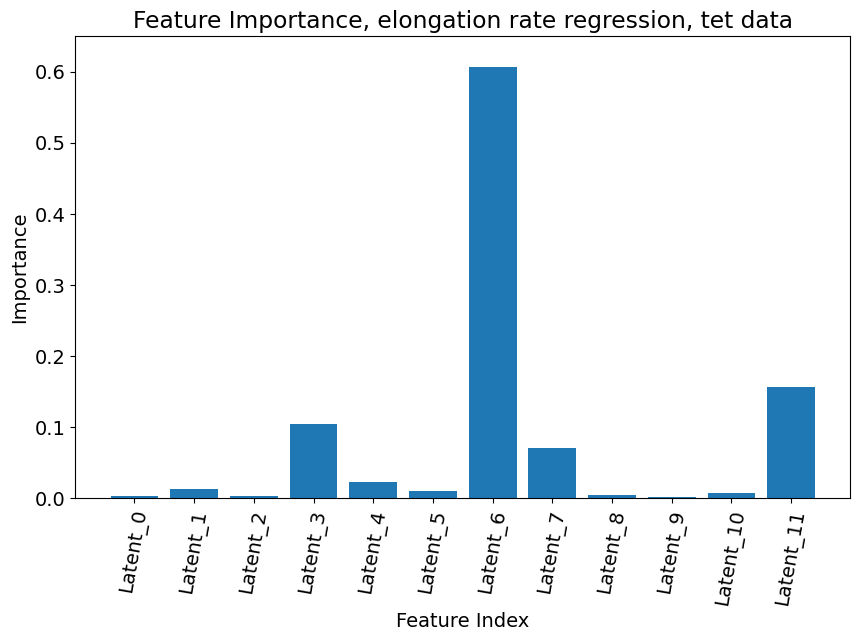

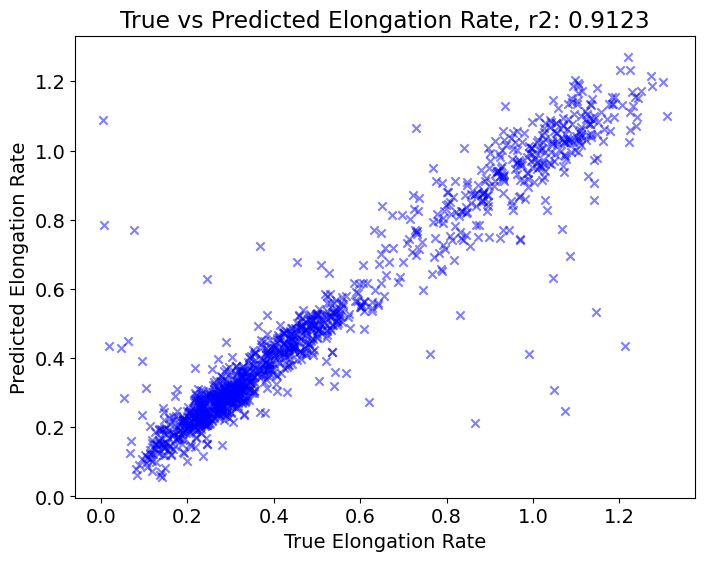

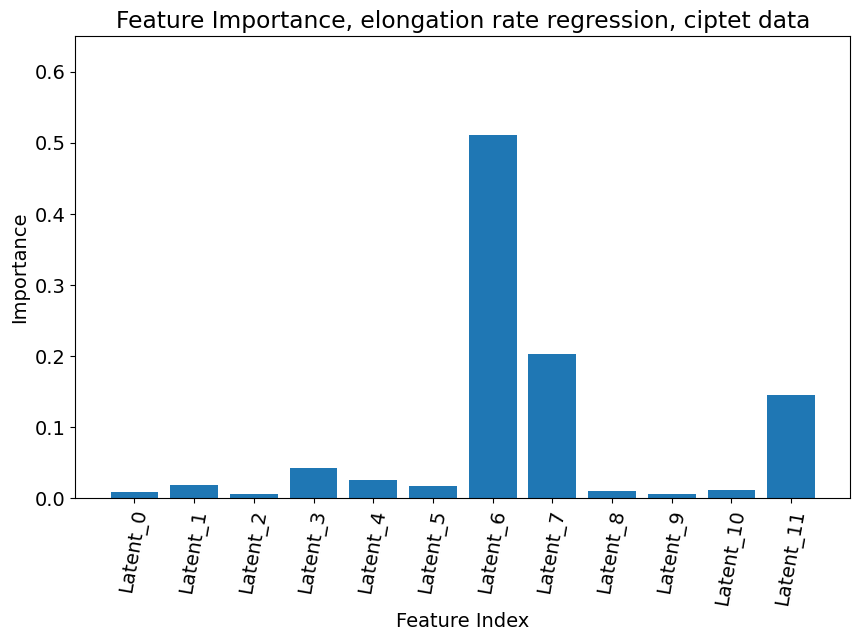

In [3]:
#######  size -> elongation rate regression
media_used = ['gly','glu','gluaa']
# conditions_used = ['control', 'cip', 'tet', 'ciptet']
# conditions_used = ['ciptet']
for conditions_used in [['control'], ['cip'], ['tet'], ['ciptet']]:
    liste_x_reg= []
    liste_y_reg = []
    for i in range(len(liste_y)):
        medium,treatment,replicate,t_death = liste_y[i]
        if medium in media_used and treatment in conditions_used:
            size_serie, rate_serie = liste_x[i][0], liste_x[i][-1] 
            for j in range(0, len(size_serie) - 72 + 1, 72):
                liste_x_reg.append(size_serie[j:j + 72])
                liste_y_reg.append(np.nanmean(rate_serie[j:j + 72]))
                if np.isnan(liste_y_reg[-1]):
                    print(f"NaN value found in target variable for track {i}, segment starting at index {j}. Skipping this segment.")
                    liste_x_reg.pop()
                    liste_y_reg.pop()
    X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
    X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
    y_reg = np.array(liste_y_reg)

    X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

    r2_list = []
    n_estimators_list = [10, 50, 100, 200, 500, 1000]
    for n_estimators in n_estimators_list:
        model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2_list.append(model.score(X_test, y_test))
        print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = model.score(X_test, y_test)

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
    plt.xlabel('True Elongation Rate')
    plt.ylabel('Predicted Elongation Rate')
    plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))

    plt.figure(figsize=(10,6))
    xgboost_feature_importances = model.feature_importances_
    plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
    plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.title(fr'Feature Importance, elongation rate regression, {conditions_used[0]} data')
    plt.ylim(0, 0.65)

n_estimators: 10, r2: 0.9054, R2: 0.9123
n_estimators: 50, r2: 0.9099, R2: 0.9123
n_estimators: 100, r2: 0.9100, R2: 0.9123
n_estimators: 200, r2: 0.9090, R2: 0.9123
n_estimators: 500, r2: 0.9075, R2: 0.9123
n_estimators: 1000, r2: 0.9070, R2: 0.9123


(0.0, 0.65)

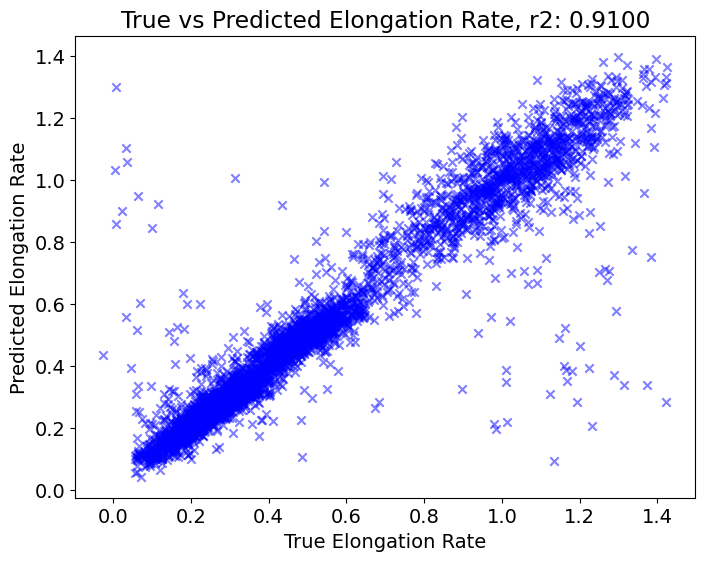

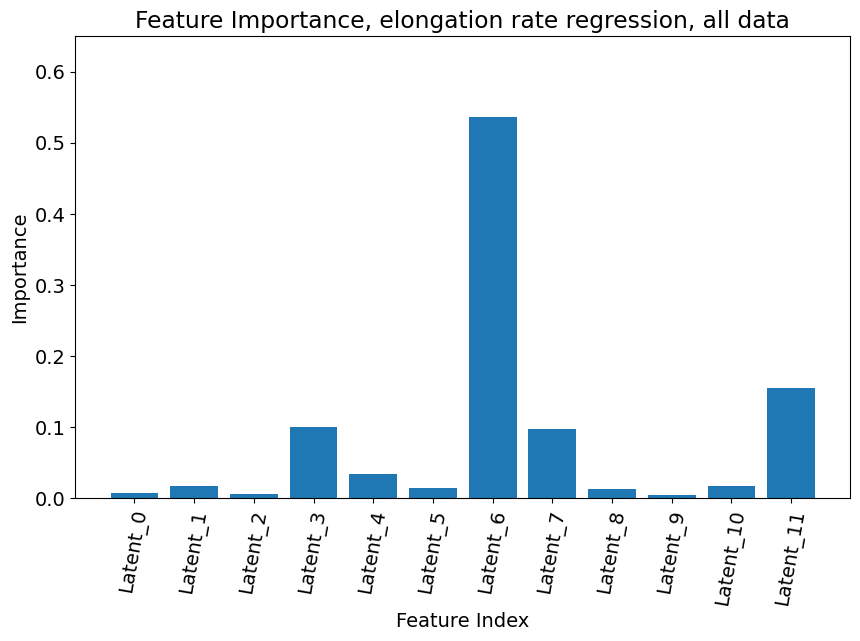

In [4]:
#######  size -> elongation rate regression all
media_used = ['gly','glu','gluaa']
conditions_used = ['control', 'cip', 'tet', 'ciptet']

liste_x_reg= []
liste_y_reg = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death = liste_y[i]
    if medium in media_used and treatment in conditions_used:
        size_serie, rate_serie = liste_x[i][0], liste_x[i][-1] 
        for j in range(0, len(size_serie) - 72 + 1, 72):
            liste_x_reg.append(size_serie[j:j + 72])
            liste_y_reg.append(np.nanmean(rate_serie[j:j + 72]))
            if np.isnan(liste_y_reg[-1]):
                print(f"NaN value found in target variable for track {i}, segment starting at index {j}. Skipping this segment.")
                liste_x_reg.pop()
                liste_y_reg.pop()
X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
y_reg = np.array(liste_y_reg)

X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

r2_list = []
n_estimators_list = [10, 50, 100, 200, 500, 1000]
for n_estimators in n_estimators_list:
    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_list.append(model.score(X_test, y_test))
    print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}, R2: {r2:.4f}")

model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
plt.xlabel('True Elongation Rate')
plt.ylabel('Predicted Elongation Rate')
plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))

plt.figure(figsize=(10,6))
xgboost_feature_importances = model.feature_importances_
plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title(fr'Feature Importance, elongation rate regression, all data')
plt.ylim(0, 0.65)

In [5]:
# #######  size -> elongation rate regression all leakage test
# media_used = ['gly','glu','gluaa']
# conditions_used = ['control', 'cip', 'tet', 'ciptet']

# X_train_list, X_test_list, y_train_list, y_test_list = train_test_split(liste_x, liste_y, test_size=0.2, random_state=42, shuffle=True)



# liste_x_reg= []
# liste_y_reg = []
# for i in range(len(y_train_list)):
#     medium,treatment,replicate,t_death = y_train_list[i]
#     if medium in media_used and treatment in conditions_used:
#         size_serie, rate_serie = X_train_list[i][0], X_train_list[i][-1] 
#         for j in range(0, len(size_serie) - 72 + 1, 72):
#             liste_x_reg.append(size_serie[j:j + 72])
#             liste_y_reg.append(np.nanmean(rate_serie[j:j + 72]))
#             if np.isnan(liste_y_reg[-1]):
#                 print(f"NaN value found in target variable for track {i}, segment starting at index {j}. Skipping this segment.")
#                 liste_x_reg.pop()
#                 liste_y_reg.pop()
# X_train = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
# X_train = vrae.transform(TensorDataset(torch.from_numpy(X_train).to('cuda')))
# y_train = np.array(liste_y_reg)

# liste_x_reg= []
# liste_y_reg = []
# for i in range(len(y_test_list)):
#     medium,treatment,replicate,t_death = y_test_list[i]
#     if medium in media_used and treatment in conditions_used:
#         size_serie, rate_serie = X_test_list[i][0], X_test_list[i][-1] 
#         for j in range(0, len(size_serie) - 72 + 1, 72):
#             liste_x_reg.append(size_serie[j:j + 72])
#             liste_y_reg.append(np.nanmean(rate_serie[j:j + 72]))
#             if np.isnan(liste_y_reg[-1]):
#                 print(f"NaN value found in target variable for track {i}, segment starting at index {j}. Skipping this segment.")
#                 liste_x_reg.pop()
#                 liste_y_reg.pop()
# X_test = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
# X_test = vrae.transform(TensorDataset(torch.from_numpy(X_test).to('cuda')))
# y_test = np.array(liste_y_reg)



# r2_list = []
# n_estimators_list = [10, 50, 100, 200, 500, 1000]
# for n_estimators in n_estimators_list:
#     model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     r2_list.append(model.score(X_test, y_test))
#     print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

# model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# r2 = model.score(X_test, y_test)

# plt.rcParams.update({'font.size': 14})
# plt.figure(figsize=(8,6))
# plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
# plt.xlabel('True Elongation Rate')
# plt.ylabel('Predicted Elongation Rate')
# plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))

# plt.figure(figsize=(10,6))
# xgboost_feature_importances = model.feature_importances_
# plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
# plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
# plt.xlabel('Feature Index')
# plt.ylabel('Importance')
# plt.title(fr'Feature Importance, elongation rate regression, all data')
# plt.ylim(0, 0.65)

n_estimators: 10, r2: 0.9696
n_estimators: 50, r2: 0.9713
n_estimators: 100, r2: 0.9712
n_estimators: 200, r2: 0.9713
n_estimators: 500, r2: 0.9710
n_estimators: 1000, r2: 0.9710
n_estimators: 10, r2: 0.7745
n_estimators: 50, r2: 0.7811
n_estimators: 100, r2: 0.7809
n_estimators: 200, r2: 0.7794
n_estimators: 500, r2: 0.7790
n_estimators: 1000, r2: 0.7790
n_estimators: 10, r2: 0.9753
n_estimators: 50, r2: 0.9780
n_estimators: 100, r2: 0.9779
n_estimators: 200, r2: 0.9777
n_estimators: 500, r2: 0.9776
n_estimators: 1000, r2: 0.9776
n_estimators: 10, r2: 0.9273
n_estimators: 50, r2: 0.9294
n_estimators: 100, r2: 0.9286
n_estimators: 200, r2: 0.9274
n_estimators: 500, r2: 0.9272
n_estimators: 1000, r2: 0.9272


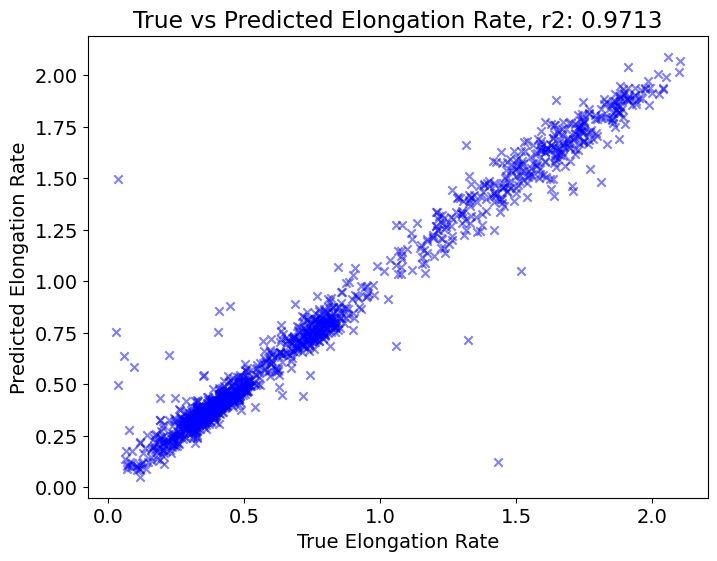

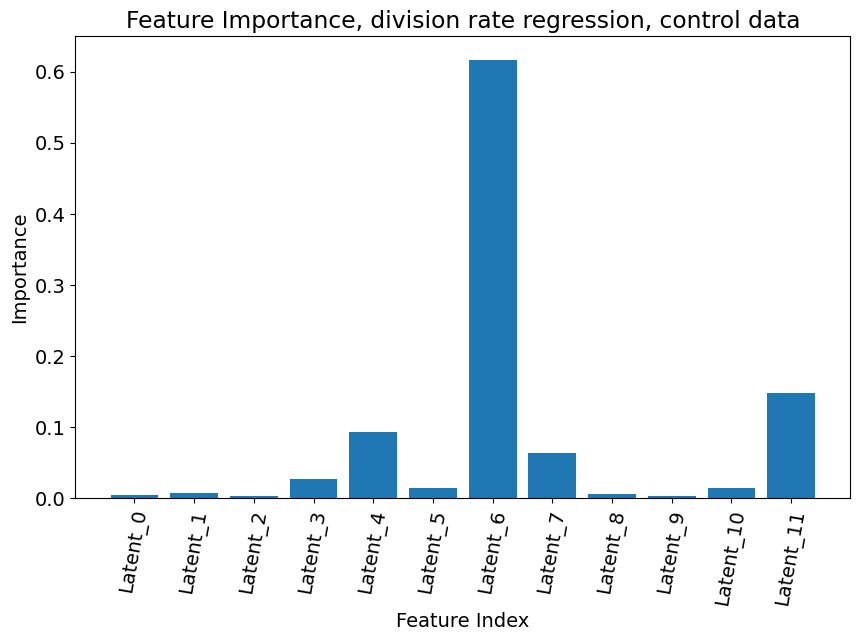

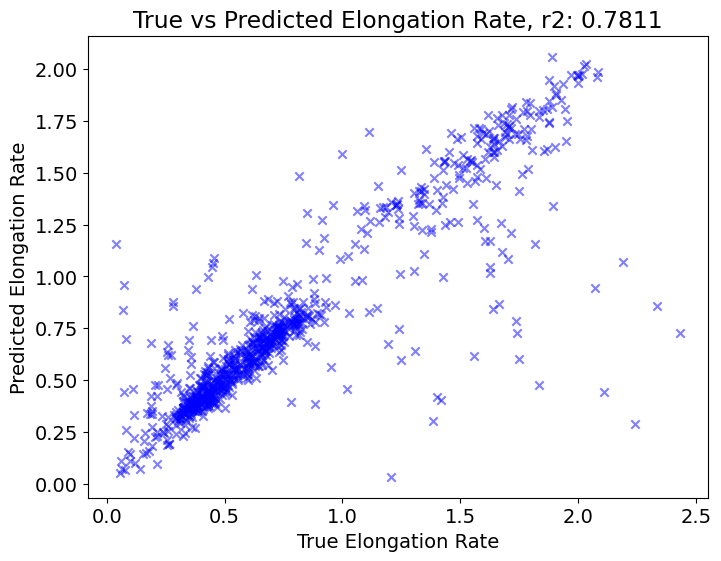

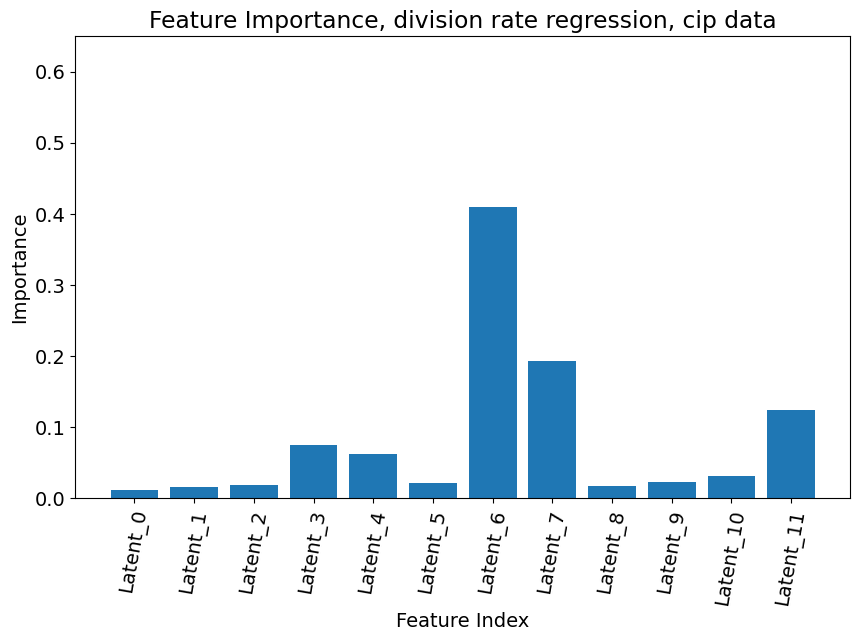

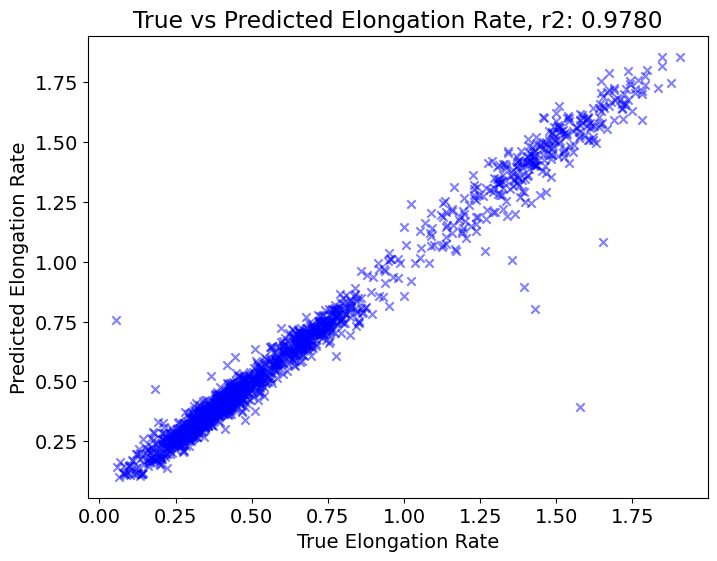

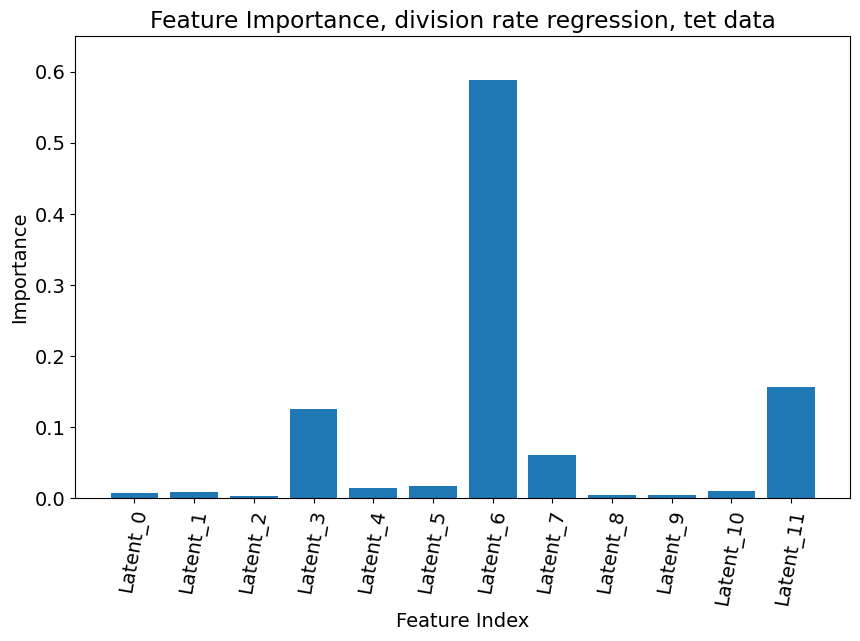

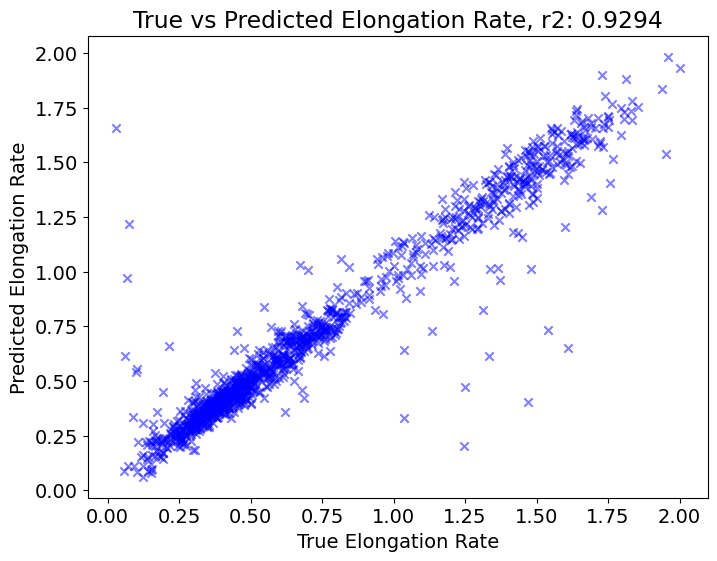

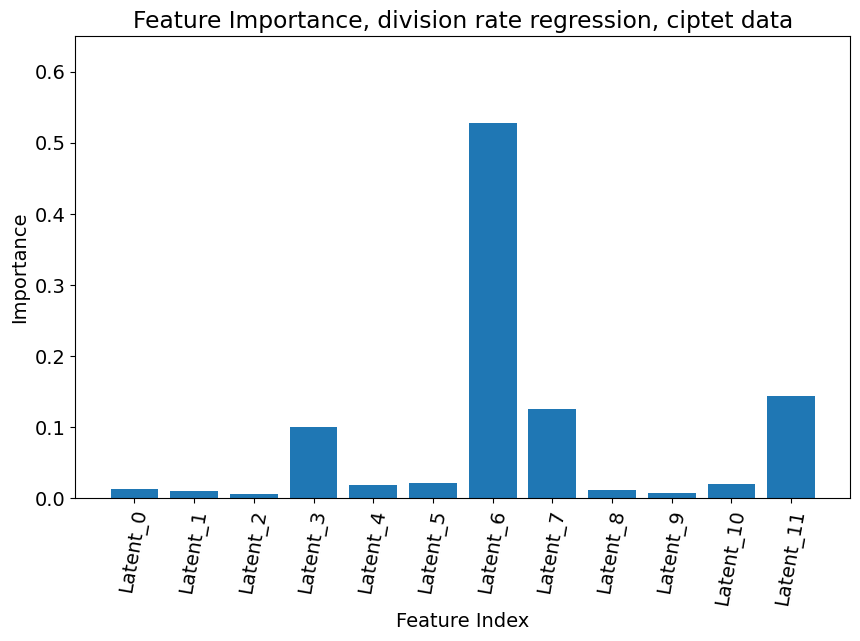

In [6]:
#######  size -> division rate regression
media_used = ['gly','glu','gluaa']
# conditions_used = ['control', 'cip', 'tet', 'ciptet']
# conditions_used = ['ciptet']
for conditions_used in [['control'], ['cip'], ['tet'], ['ciptet']]:
    liste_x_reg= []
    liste_y_reg = []
    for i in range(len(liste_y)):
        medium,treatment,replicate,t_death = liste_y[i]
        if medium in media_used and treatment in conditions_used:
            size_serie, rate_serie = liste_x[i][0], liste_x[i][-2] 
            for j in range(0, len(size_serie) - 72 + 1, 72):
                liste_x_reg.append(size_serie[j:j + 72])
                liste_y_reg.append(np.nanmean(rate_serie[j:j + 72]))
                if np.isnan(liste_y_reg[-1]):
                    print(f"NaN value found in target variable for track {i}, segment starting at index {j}. Skipping this segment.")
                    liste_x_reg.pop()
                    liste_y_reg.pop()
    X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
    X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
    y_reg = np.array(liste_y_reg)

    X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

    r2_list = []
    n_estimators_list = [10, 50, 100, 200, 500, 1000]
    for n_estimators in n_estimators_list:
        model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2_list.append(model.score(X_test, y_test))
        print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = model.score(X_test, y_test)

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
    plt.xlabel('True Elongation Rate')
    plt.ylabel('Predicted Elongation Rate')
    plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))

    plt.figure(figsize=(10,6))
    xgboost_feature_importances = model.feature_importances_
    plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
    plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.title(fr'Feature Importance, division rate regression, {conditions_used[0]} data')
    plt.ylim(0, 0.65)

n_estimators: 10, r2: 0.9216
n_estimators: 50, r2: 0.9296
n_estimators: 100, r2: 0.9298
n_estimators: 200, r2: 0.9291
n_estimators: 500, r2: 0.9286
n_estimators: 1000, r2: 0.9285


(0.0, 0.65)

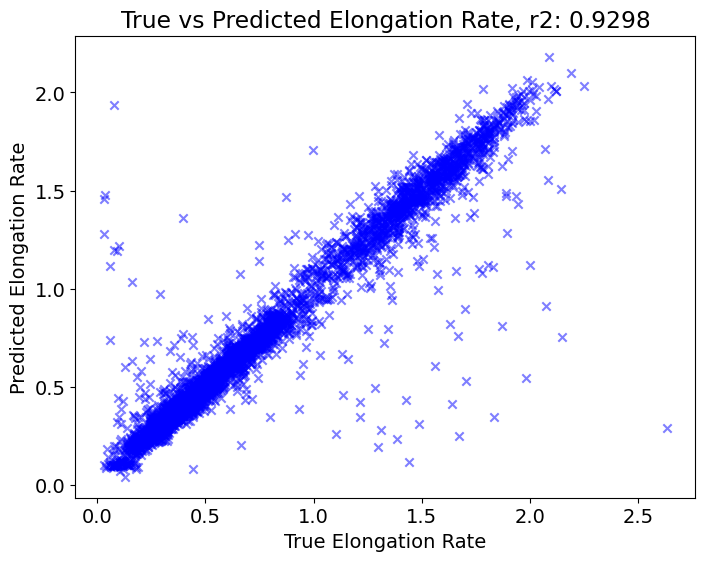

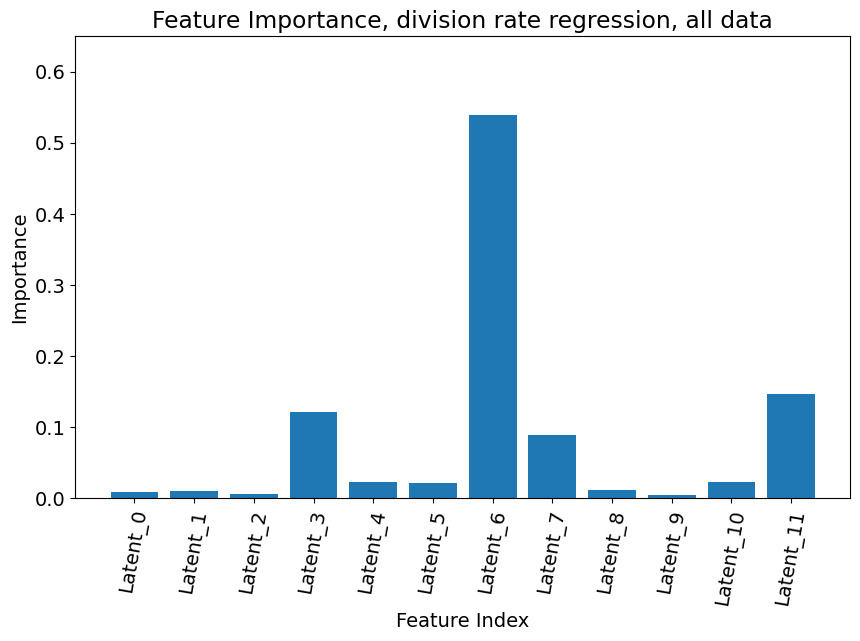

In [7]:
#######  size -> division rate regression all
media_used = ['gly','glu','gluaa']
conditions_used = ['control', 'cip', 'tet', 'ciptet']

liste_x_reg= []
liste_y_reg = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death = liste_y[i]
    if medium in media_used and treatment in conditions_used:
        size_serie, rate_serie = liste_x[i][0], liste_x[i][-2] 
        for j in range(0, len(size_serie) - 72 + 1, 72):
            liste_x_reg.append(size_serie[j:j + 72])
            liste_y_reg.append(np.nanmean(rate_serie[j:j + 72]))
            if np.isnan(liste_y_reg[-1]):
                print(f"NaN value found in target variable for track {i}, segment starting at index {j}. Skipping this segment.")
                liste_x_reg.pop()
                liste_y_reg.pop()
X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
y_reg = np.array(liste_y_reg)

X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

r2_list = []
n_estimators_list = [10, 50, 100, 200, 500, 1000]
for n_estimators in n_estimators_list:
    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_list.append(model.score(X_test, y_test))
    print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
plt.xlabel('True Elongation Rate')
plt.ylabel('Predicted Elongation Rate')
plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))

plt.figure(figsize=(10,6))
xgboost_feature_importances = model.feature_importances_
plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title(fr'Feature Importance, division rate regression, all data')
plt.ylim(0, 0.65)

n_estimators: 10, r2: 0.8719
n_estimators: 50, r2: 0.8698
n_estimators: 100, r2: 0.8656
n_estimators: 200, r2: 0.8602
n_estimators: 500, r2: 0.8578
n_estimators: 1000, r2: 0.8578
n_estimators: 10, r2: 0.5716
n_estimators: 50, r2: 0.5637
n_estimators: 100, r2: 0.5588
n_estimators: 200, r2: 0.5502
n_estimators: 500, r2: 0.5493
n_estimators: 1000, r2: 0.5493
n_estimators: 10, r2: 0.7850
n_estimators: 50, r2: 0.7752
n_estimators: 100, r2: 0.7663
n_estimators: 200, r2: 0.7595
n_estimators: 500, r2: 0.7543
n_estimators: 1000, r2: 0.7538
n_estimators: 10, r2: 0.7518
n_estimators: 50, r2: 0.7417
n_estimators: 100, r2: 0.7358
n_estimators: 200, r2: 0.7308
n_estimators: 500, r2: 0.7267
n_estimators: 1000, r2: 0.7267


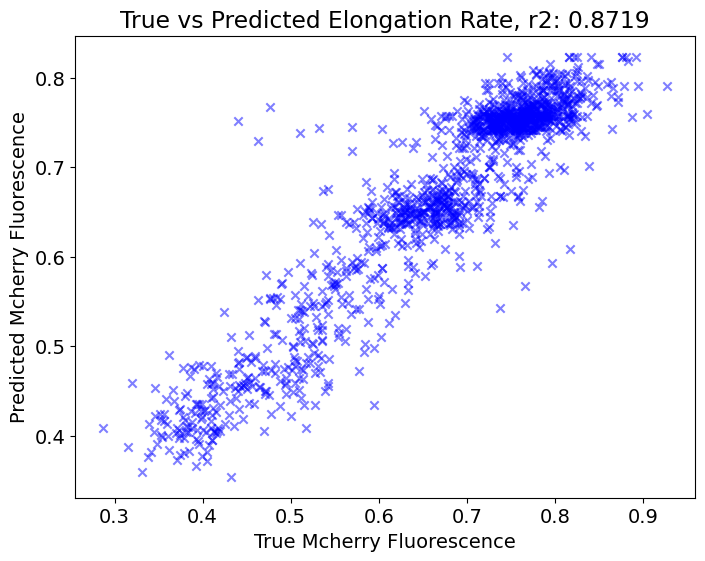

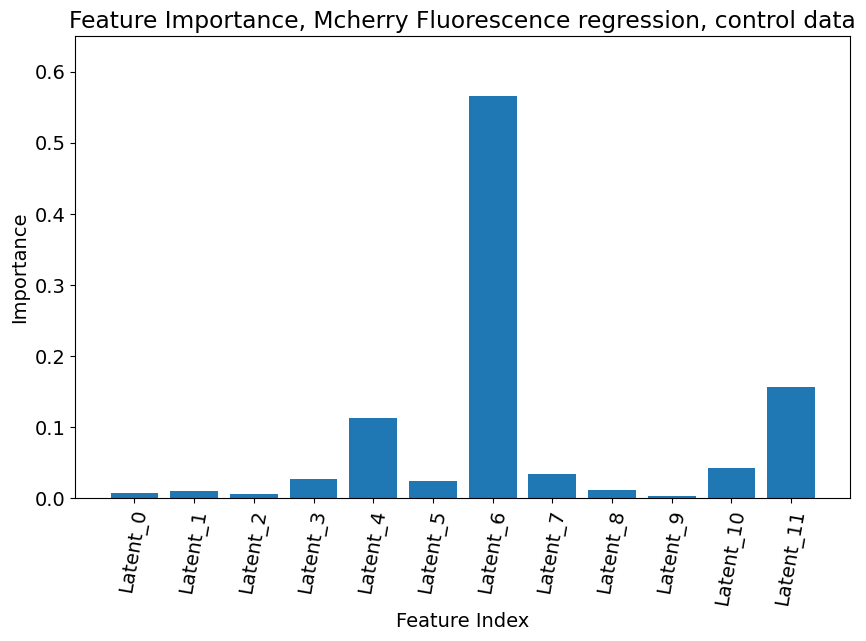

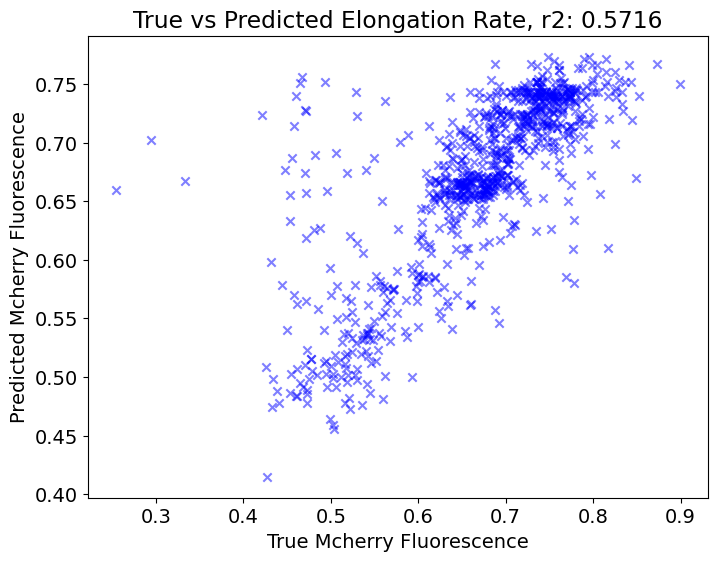

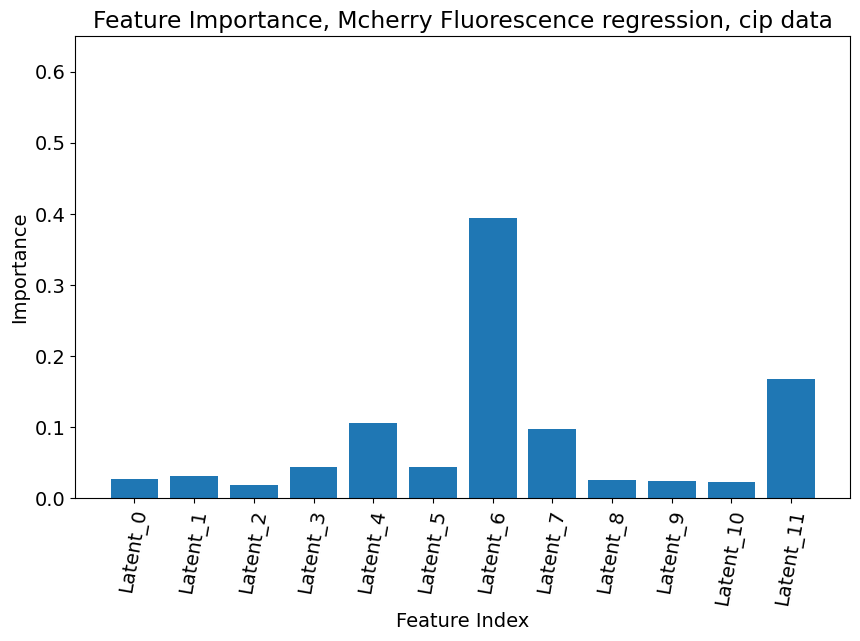

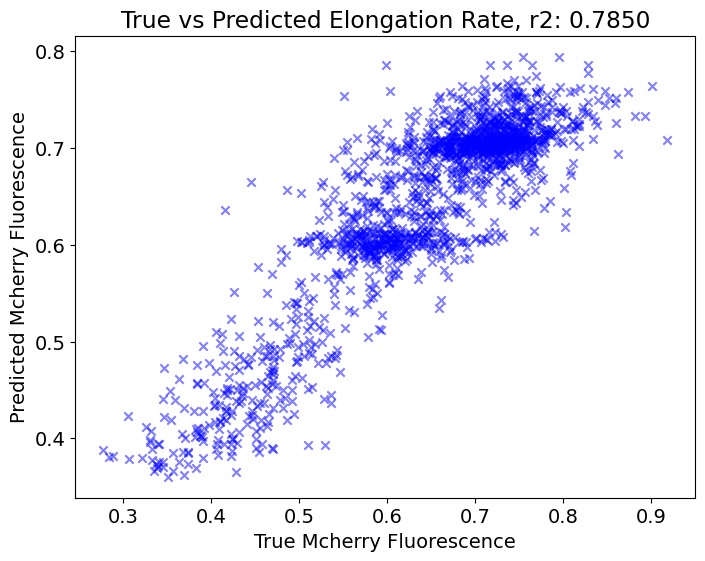

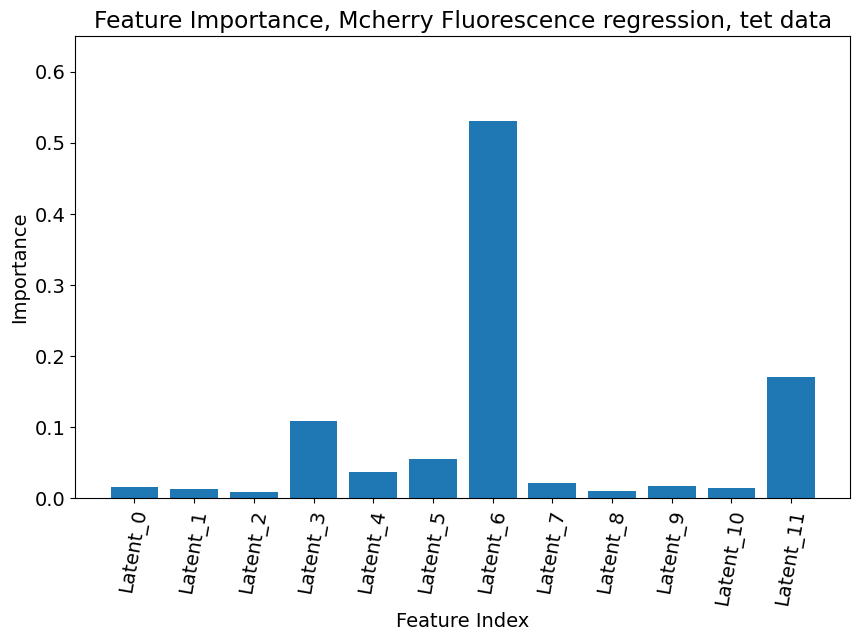

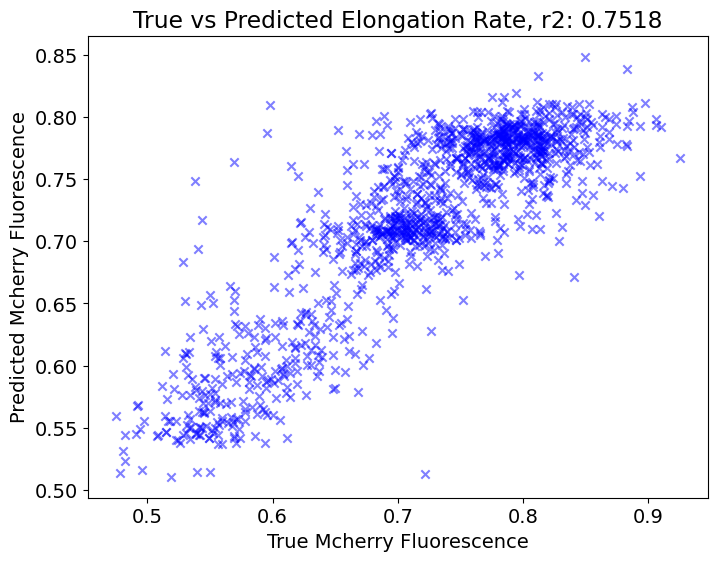

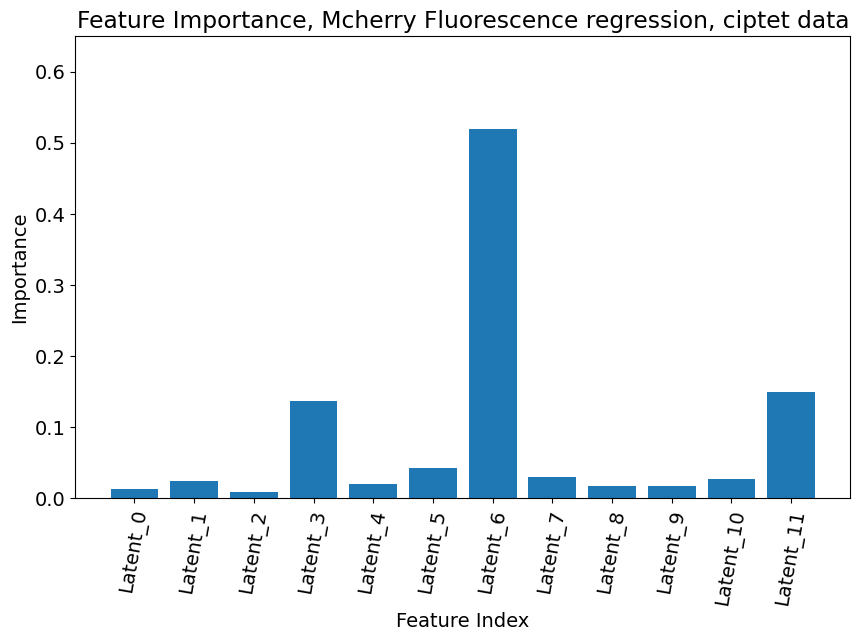

In [8]:
#######  size -> Mcherry Fluorescence rate regression
feature_name = 'Mcherry Fluorescence'
media_used = ['gly','glu','gluaa']
# conditions_used = ['control', 'cip', 'tet', 'ciptet']
# conditions_used = ['ciptet']
for conditions_used in [['control'], ['cip'], ['tet'], ['ciptet']]:
    liste_x_reg= []
    liste_y_reg = []
    for i in range(len(liste_y)):
        medium,treatment,replicate,t_death = liste_y[i]
        if medium in media_used and treatment in conditions_used:
            size_serie, fluo_serie = liste_x[i][0], liste_x[i][2] 
            for j in range(0, len(size_serie) - 72 + 1, 72):
                liste_x_reg.append(size_serie[j:j + 72])
                liste_y_reg.append(fluo_serie[j:j + 72])
    liste_y_reg = my_scaler(liste_y_reg)
    liste_y_reg = [np.nanmean(serie) for serie in liste_y_reg]

    X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
    X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
    y_reg = np.array(liste_y_reg)

    X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

    r2_list = []
    n_estimators_list = [10, 50, 100, 200, 500, 1000]
    for n_estimators in n_estimators_list:
        model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2_list.append(model.score(X_test, y_test))
        print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = model.score(X_test, y_test)

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
    plt.xlabel(f'True {feature_name}')
    plt.ylabel(f'Predicted {feature_name}')
    plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))

    plt.figure(figsize=(10,6))
    xgboost_feature_importances = model.feature_importances_
    plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
    plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.title(fr'Feature Importance, {feature_name} regression, {conditions_used[0]} data')
    plt.ylim(0, 0.65)

n_estimators: 10, r2: 0.7672
n_estimators: 50, r2: 0.7725
n_estimators: 100, r2: 0.7712
n_estimators: 200, r2: 0.7680
n_estimators: 500, r2: 0.7576
n_estimators: 1000, r2: 0.7530


(0.0, 0.65)

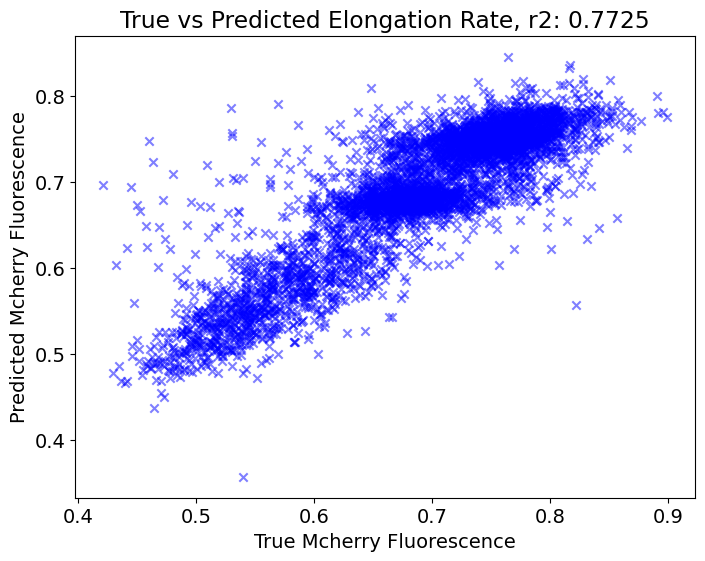

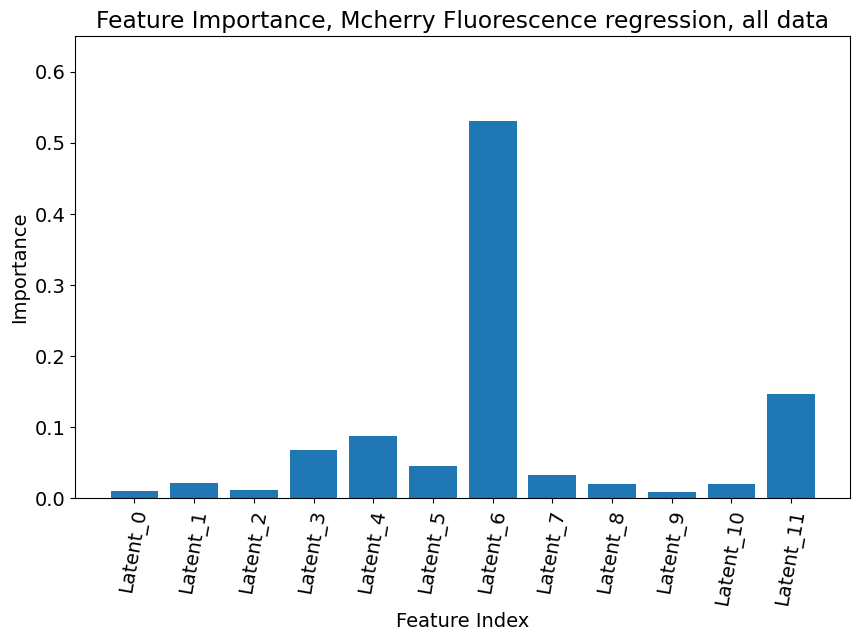

In [9]:
#######  size -> Mcherry Fluorescence rate regression all
feature_name = 'Mcherry Fluorescence'
media_used = ['gly','glu','gluaa']
conditions_used = ['control', 'cip', 'tet', 'ciptet']
liste_x_reg= []
liste_y_reg = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death = liste_y[i]
    if medium in media_used and treatment in conditions_used:
        size_serie, fluo_serie = liste_x[i][0], liste_x[i][2] 
        for j in range(0, len(size_serie) - 72 + 1, 72):
            liste_x_reg.append(size_serie[j:j + 72])
            liste_y_reg.append(fluo_serie[j:j + 72])
liste_y_reg = my_scaler(liste_y_reg)
liste_y_reg = [np.nanmean(serie) for serie in liste_y_reg]

X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
y_reg = np.array(liste_y_reg)

X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

r2_list = []
n_estimators_list = [10, 50, 100, 200, 500, 1000]
for n_estimators in n_estimators_list:
    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_list.append(model.score(X_test, y_test))
    print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
plt.xlabel(f'True {feature_name}')
plt.ylabel(f'Predicted {feature_name}')
plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))

plt.figure(figsize=(10,6))
xgboost_feature_importances = model.feature_importances_
plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title(fr'Feature Importance, {feature_name} regression, all data')
plt.ylim(0, 0.65)

n_estimators: 10, r2: 0.0155
n_estimators: 50, r2: -0.0579
n_estimators: 100, r2: -0.1078
n_estimators: 200, r2: -0.1515
n_estimators: 500, r2: -0.1871
n_estimators: 1000, r2: -0.1885
n_estimators: 10, r2: 0.1190
n_estimators: 50, r2: 0.0654
n_estimators: 100, r2: 0.0288
n_estimators: 200, r2: 0.0028
n_estimators: 500, r2: -0.0058
n_estimators: 1000, r2: -0.0058
n_estimators: 10, r2: 0.0404
n_estimators: 50, r2: -0.0185
n_estimators: 100, r2: -0.0779
n_estimators: 200, r2: -0.1314
n_estimators: 500, r2: -0.1673
n_estimators: 1000, r2: -0.1689
n_estimators: 10, r2: 0.0969
n_estimators: 50, r2: 0.0535
n_estimators: 100, r2: -0.0138
n_estimators: 200, r2: -0.0499
n_estimators: 500, r2: -0.0581
n_estimators: 1000, r2: -0.0581


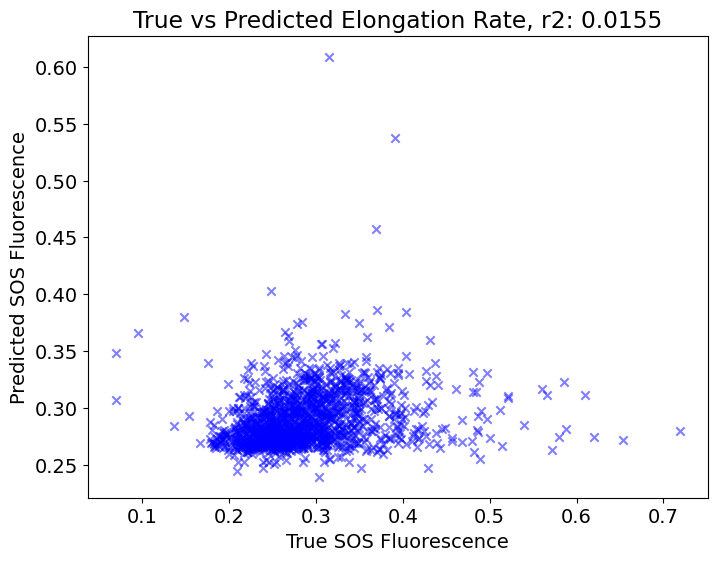

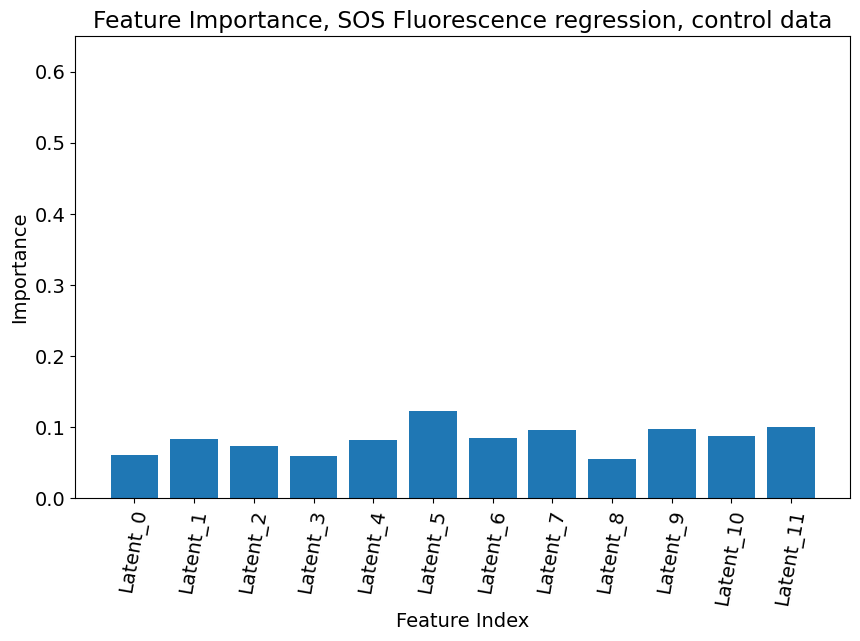

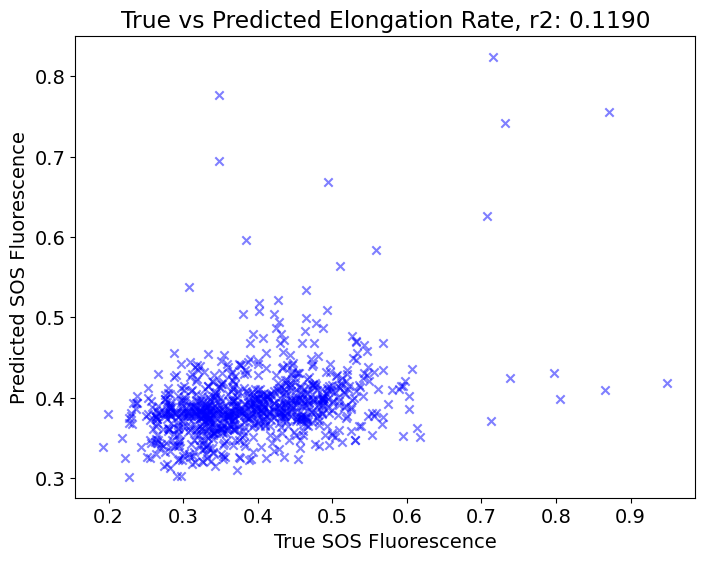

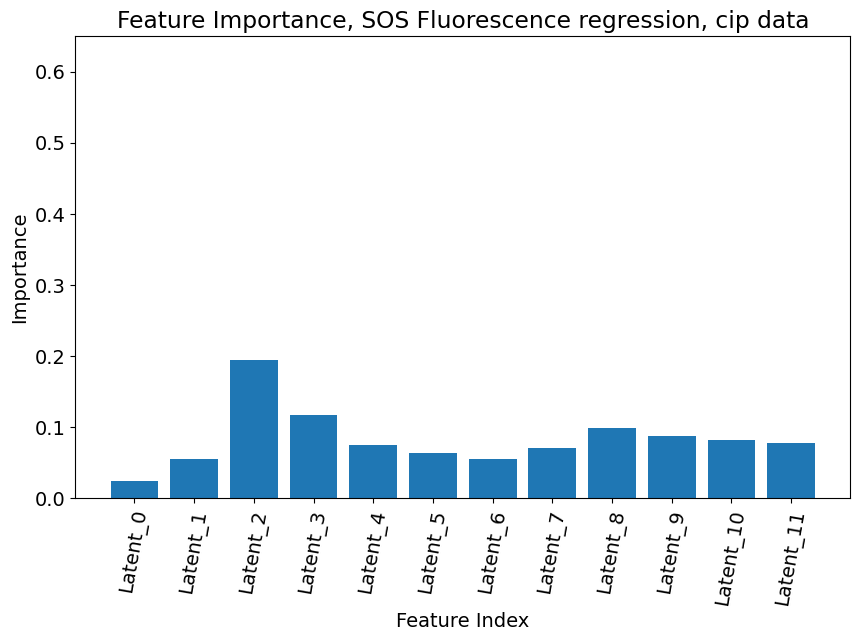

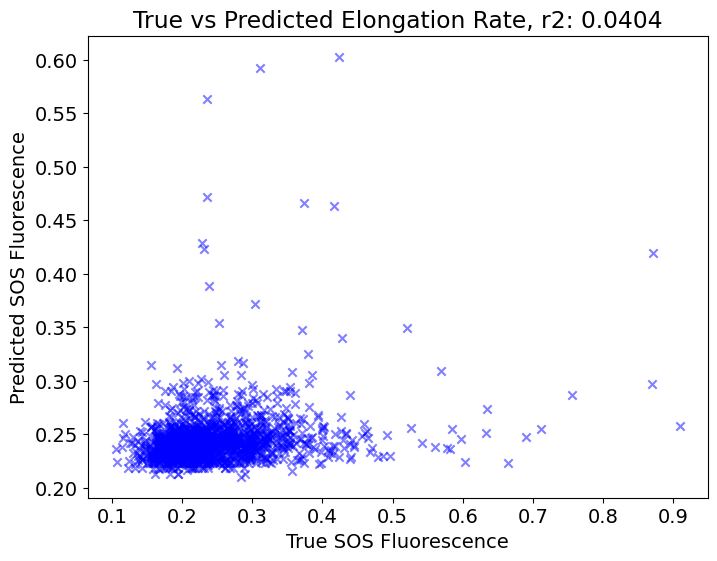

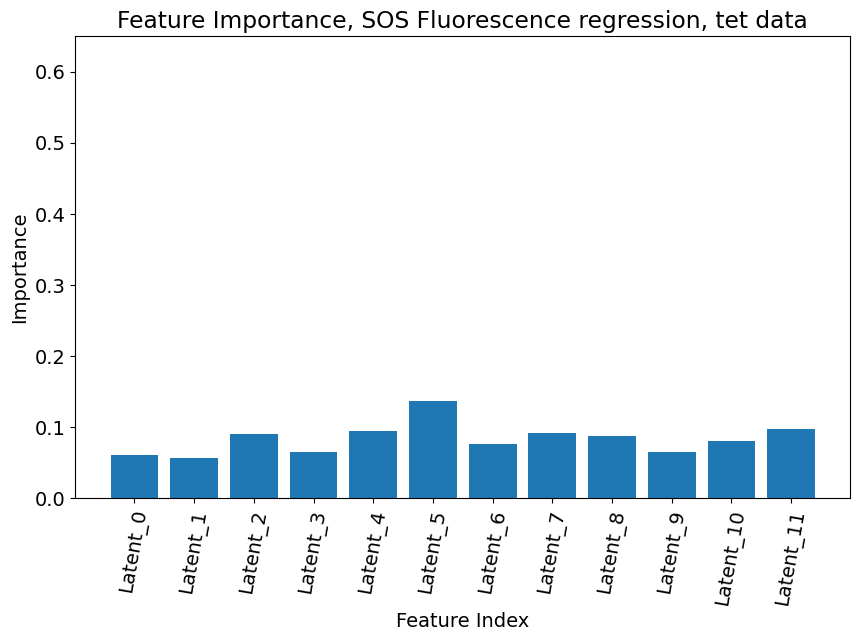

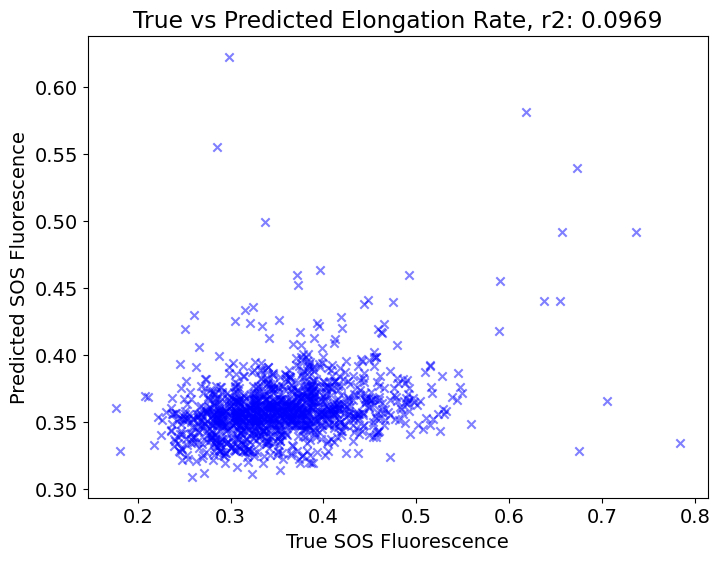

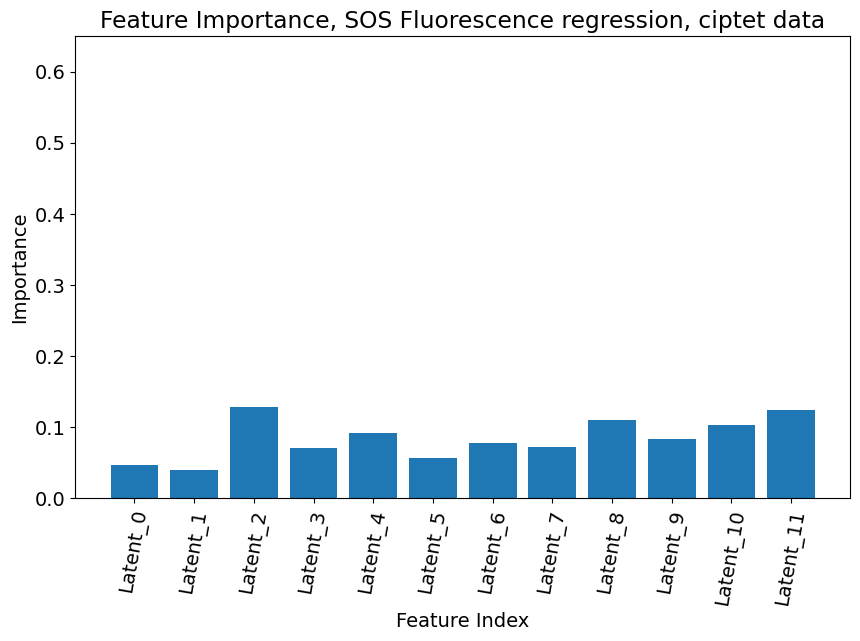

In [10]:
#######  size -> SOS Fluorescence rate regression
feature_name = 'SOS Fluorescence'
media_used = ['gly','glu','gluaa']
# conditions_used = ['control', 'cip', 'tet', 'ciptet']
# conditions_used = ['ciptet']
for conditions_used in [['control'], ['cip'], ['tet'], ['ciptet']]:
    liste_x_reg= []
    liste_y_reg = []
    for i in range(len(liste_y)):
        medium,treatment,replicate,t_death = liste_y[i]
        if medium in media_used and treatment in conditions_used:
            size_serie, fluo_serie = liste_x[i][0], liste_x[i][1] 
            for j in range(0, len(size_serie) - 72 + 1, 72):
                liste_x_reg.append(size_serie[j:j + 72])
                liste_y_reg.append(fluo_serie[j:j + 72])
    liste_y_reg = my_scaler(liste_y_reg)
    liste_y_reg = [np.nanmean(serie) for serie in liste_y_reg]

    X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
    X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
    y_reg = np.array(liste_y_reg)

    X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

    r2_list = []
    n_estimators_list = [10, 50, 100, 200, 500, 1000]
    for n_estimators in n_estimators_list:
        model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2_list.append(model.score(X_test, y_test))
        print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = model.score(X_test, y_test)

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
    plt.xlabel(f'True {feature_name}')
    plt.ylabel(f'Predicted {feature_name}')
    plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))   

    plt.figure(figsize=(10,6))
    xgboost_feature_importances = model.feature_importances_
    plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
    plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.title(fr'Feature Importance, {feature_name} regression, {conditions_used[0]} data')
    plt.ylim(0, 0.65)

n_estimators: 10, r2: 0.1182
n_estimators: 50, r2: 0.1237
n_estimators: 100, r2: 0.0938
n_estimators: 200, r2: 0.0684
n_estimators: 500, r2: 0.0036
n_estimators: 1000, r2: -0.0234


(0.0, 0.65)

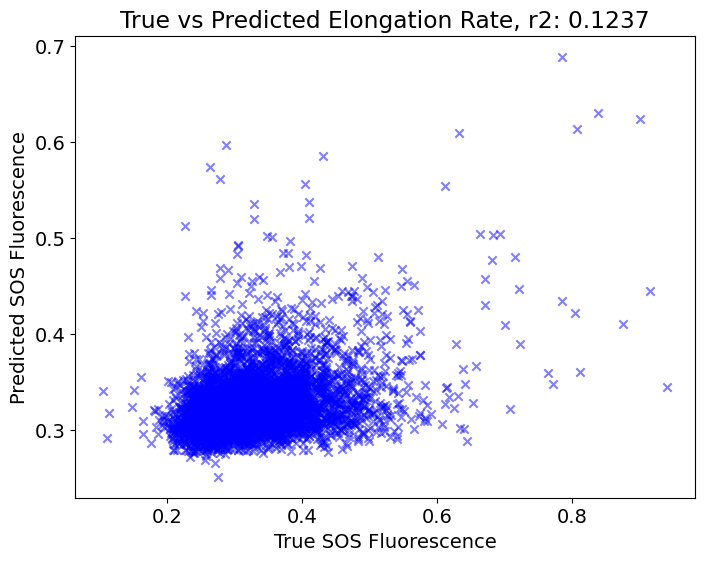

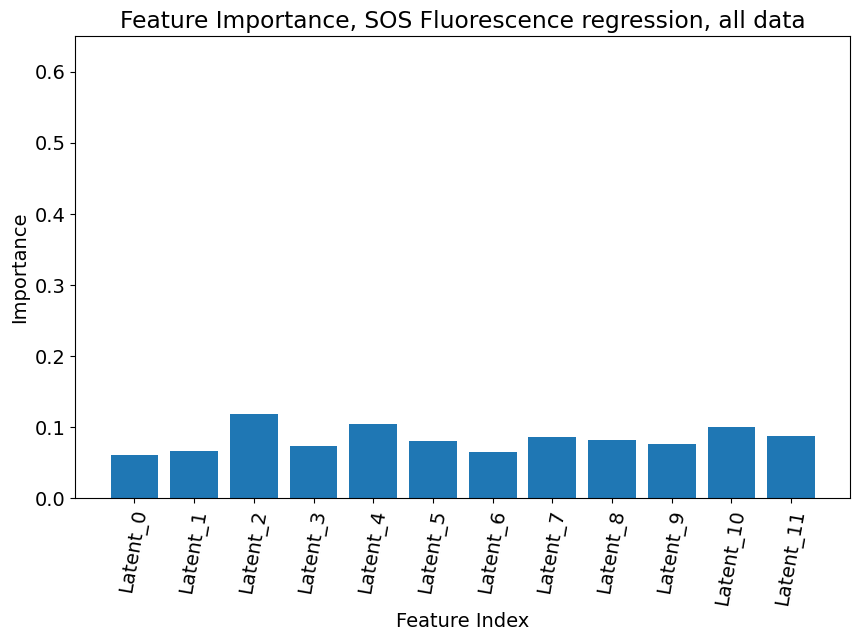

In [11]:
#######  size -> SOS Fluorescence rate regression all
feature_name = 'SOS Fluorescence'
media_used = ['gly','glu','gluaa']
conditions_used = ['control', 'cip', 'tet', 'ciptet']

liste_x_reg= []
liste_y_reg = []
for i in range(len(liste_y)):
    medium,treatment,replicate,t_death = liste_y[i]
    if medium in media_used and treatment in conditions_used:
        size_serie, fluo_serie = liste_x[i][0], liste_x[i][1] 
        for j in range(0, len(size_serie) - 72 + 1, 72):
            liste_x_reg.append(size_serie[j:j + 72])
            liste_y_reg.append(fluo_serie[j:j + 72])
liste_y_reg = my_scaler(liste_y_reg)
liste_y_reg = [np.nanmean(serie) for serie in liste_y_reg]

X_reg = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_reg))
X_proj = vrae.transform(TensorDataset(torch.from_numpy(X_reg).to('cuda')))
y_reg = np.array(liste_y_reg)

X_train, X_test, y_train, y_test = train_test_split(X_proj, y_reg, test_size=0.2, random_state=42, shuffle=True)

r2_list = []
n_estimators_list = [10, 50, 100, 200, 500, 1000]
for n_estimators in n_estimators_list:
    model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_list.append(model.score(X_test, y_test))
    print(f"n_estimators: {n_estimators}, r2: {model.score(X_test, y_test):.4f}")

model = xgb.XGBRegressor(random_state=42, n_estimators=n_estimators_list[np.argmax(r2_list)])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='b',marker='x')
plt.xlabel(f'True {feature_name}')
plt.ylabel(f'Predicted {feature_name}')
plt.title('True vs Predicted Elongation Rate, r2: {:.4f}'.format(model.score(X_test, y_test)))   

plt.figure(figsize=(10,6))
xgboost_feature_importances = model.feature_importances_
plt.bar(range(len(xgboost_feature_importances)), xgboost_feature_importances)
plt.xticks(range(len(xgboost_feature_importances)), [f'Latent_{i}' for i in range(len(xgboost_feature_importances))], rotation=80)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title(fr'Feature Importance, {feature_name} regression, all data')
plt.ylim(0, 0.65)

In [24]:
len(liste_x)
print(f"Total number of tracks: {len(liste_x)}")

Total number of tracks: 7600
